In [610]:

import keras
from keras import layers
import tensorflow as tf
import numpy as np



In [ ]:
batch_size = 64
num_channels = 1
num_classes = 26
image_size = 28
latent_dim = 128

all_letters = np.load('/content/sample_data/x_letters.npy')
all_labels = np.load('/content/sample_data/y_letters.npy')


all_letters = all_letters.astype("float32")
all_letters = np.reshape(all_letters, (-1, 28, 28, 1))
all_labels = keras.utils.to_categorical(all_labels, num_classes)

dataset = tf.data.Dataset.from_tensor_slices((all_letters, all_labels))
dataset = dataset.shuffle(buffer_size=1024).batch(batch_size)

print(f"Shape of training images: {all_letters.shape}")
print(f"Shape of training labels: {all_labels.shape}")

Shape of training images: (88799, 28, 28, 1)
Shape of training labels: (88799, 26)


In [612]:
generator_in_channels = latent_dim + num_classes
discriminator_in_channels = num_channels + num_classes
print(generator_in_channels, discriminator_in_channels)

154 27


In [ ]:
discriminator = keras.Sequential(
    [
        keras.layers.InputLayer((28, 28, discriminator_in_channels)),
        layers.Conv2D(64, (3, 3), strides=(2, 2), padding="same"),
        layers.LeakyReLU(),
        layers.Conv2D(128, (3, 3), strides=(2, 2), padding="same"),
        layers.LeakyReLU(),
        layers.GlobalMaxPooling2D(),
        layers.Dense(1),
    ],
    name="discriminator",
)

generator = keras.Sequential(
    [
        keras.layers.InputLayer((generator_in_channels,)),
        layers.Dense(7 * 7 * generator_in_channels),
        layers.LeakyReLU(),
        layers.Reshape((7, 7, generator_in_channels)),
        layers.Conv2DTranspose(128, (4, 4), strides=(2, 2), padding="same"),
        layers.LeakyReLU(),
        layers.Conv2DTranspose(128, (4, 4), strides=(2, 2), padding="same"),
        layers.LeakyReLU(),
        layers.Conv2D(1, (7, 7), padding="same", activation="sigmoid"),
    ],
    name="generator",
)

In [ ]:

class ConditionalGAN(keras.Model):
    def __init__(self, discriminator, generator, latent_dim):
        super().__init__()
        self.discriminator = discriminator
        self.generator = generator
        self.latent_dim = latent_dim
        self.seed_generator = keras.random.SeedGenerator(1337)
        self.gen_loss_tracker = keras.metrics.Mean(name="generator_loss")
        self.disc_loss_tracker = keras.metrics.Mean(name="discriminator_loss")

    @property
    def metrics(self):
        return [self.gen_loss_tracker, self.disc_loss_tracker]

    def compile(self, d_optimizer, g_optimizer, loss_fn):
        super().compile()
        self.d_optimizer = d_optimizer
        self.g_optimizer = g_optimizer
        self.loss_fn = loss_fn

    def train_step(self, data):
        real_images, one_hot_labels = data

        batch_size = tf.shape(real_images)[0]
        image_one_hot_labels = tf.reshape(one_hot_labels, (batch_size, 1, 1, num_classes))
        image_one_hot_labels = tf.tile(image_one_hot_labels, [1, image_size, image_size, 1])

        batch_size = ops.shape(real_images)[0]
        random_latent_vectors = keras.random.normal(
            shape=(batch_size, self.latent_dim), seed=self.seed_generator
        )
        random_vector_labels = ops.concatenate(
            [random_latent_vectors, one_hot_labels], axis=1
        )

        generated_images = self.generator(random_vector_labels)

        fake_image_and_labels = ops.concatenate(
            [generated_images, image_one_hot_labels], -1
        )
        real_image_and_labels = ops.concatenate([real_images, image_one_hot_labels], -1)
        combined_images = ops.concatenate(
            [fake_image_and_labels, real_image_and_labels], axis=0
        )

        labels = ops.concatenate(
            [ops.ones((batch_size, 1)), ops.zeros((batch_size, 1))], axis=0
        )

        labels += 0.05 * tf.random.uniform(tf.shape(labels))

        with tf.GradientTape() as tape:
            predictions = self.discriminator(combined_images)
            d_loss = self.loss_fn(labels, predictions)
        grads = tape.gradient(d_loss, self.discriminator.trainable_weights)
        self.d_optimizer.apply_gradients(
            zip(grads, self.discriminator.trainable_weights)
        )


        random_latent_vectors = keras.random.normal(
            shape=(batch_size, self.latent_dim), seed=self.seed_generator
        )
        random_vector_labels = ops.concatenate(
            [random_latent_vectors, one_hot_labels], axis=1
        )


        misleading_labels = ops.zeros((batch_size, 1))


        with tf.GradientTape() as tape:
            fake_images = self.generator(random_vector_labels)
            fake_image_and_labels = ops.concatenate(
                [fake_images, image_one_hot_labels], -1
            )
            predictions = self.discriminator(fake_image_and_labels)
            g_loss = self.loss_fn(misleading_labels, predictions)
        grads = tape.gradient(g_loss, self.generator.trainable_weights)
        self.g_optimizer.apply_gradients(zip(grads, self.generator.trainable_weights))


        self.gen_loss_tracker.update_state(g_loss)
        self.disc_loss_tracker.update_state(d_loss)
        return {
            "g_loss": self.gen_loss_tracker.result(),
            "d_loss": self.disc_loss_tracker.result(),
        }


In [615]:
cond_gan = ConditionalGAN(
    discriminator=discriminator, generator=generator, latent_dim=latent_dim
)
cond_gan.compile(
    d_optimizer=keras.optimizers.Adam(learning_rate=0.0002),
    g_optimizer=keras.optimizers.Adam(learning_rate=0.0002),
    loss_fn=keras.losses.BinaryCrossentropy(from_logits=True),
)

cond_gan.fit(dataset, epochs=30)

Epoch 1/30
1388/1388 ━━━━━━━━━━━━━━━━━━━━ 42s 26ms/step - d_loss: 0.5237 - g_loss: 1.1774
Epoch 2/30
1388/1388 ━━━━━━━━━━━━━━━━━━━━ 33s 24ms/step - d_loss: 0.5437 - g_loss: 1.1687
Epoch 3/30
1388/1388 ━━━━━━━━━━━━━━━━━━━━ 33s 24ms/step - d_loss: 0.4277 - g_loss: 1.6378
Epoch 4/30
1388/1388 ━━━━━━━━━━━━━━━━━━━━ 33s 24ms/step - d_loss: 0.6186 - g_loss: 0.9285
Epoch 5/30
1388/1388 ━━━━━━━━━━━━━━━━━━━━ 33s 24ms/step - d_loss: 0.6190 - g_loss: 0.9142
Epoch 6/30
1388/1388 ━━━━━━━━━━━━━━━━━━━━ 33s 24ms/step - d_loss: 0.6410 - g_loss: 0.8757
Epoch 7/30
1388/1388 ━━━━━━━━━━━━━━━━━━━━ 33s 24ms/step - d_loss: 0.6355 - g_loss: 0.8817
Epoch 8/30
1388/1388 ━━━━━━━━━━━━━━━━━━━━ 33s 24ms/step - d_loss: 0.6269 - g_loss: 0.9033
Epoch 9/30
1388/1388 ━━━━━━━━━━━━━━━━━━━━ 33s 24ms/step - d_loss: 0.6286 - g_loss: 0.8989
Epoch 10/30
1388/1388 ━━━━━━━━━━━━━━━━━━━━ 33s 24ms/step - d_loss: 0.6311 - g_loss: 0.8905
Epoch 11/30
1388/1388 ━━━━━━━━━━━━━━━━━━━━ 33s 24ms/step - d_loss: 0.6255 - g_loss: 0.9019
Epoch 12

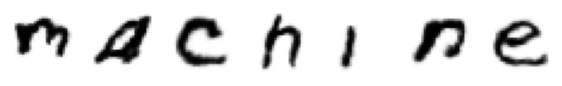

In [ ]:
import numpy as np
import keras
from keras import ops
import matplotlib.pyplot as plt


trained_gen = cond_gan.generator


letter_to_id = {chr(i+65): i for i in range(26)}

def generate_letter(letter_id):
    noise = keras.random.normal(shape=(1, latent_dim))
    label = ops.cast(keras.utils.to_categorical([letter_id], num_classes), "float32")
    img = trained_gen.predict(ops.concatenate([noise, label], axis=1), verbose=0)
    img = (img[0][:, :, 0] * 255).astype(np.uint8)
    img = 255 - img  
    return img

def generate_word(word):
    word = word.upper()  
    images = [generate_letter(letter_to_id[c]) for c in word if c in letter_to_id]
    plt.figure(figsize=(len(images), 2))
    for i, img in enumerate(images):
        plt.subplot(1, len(images), i+1)
        plt.imshow(img, cmap='gray')
        plt.axis('off')
    plt.show()

generate_word("MACHINE")


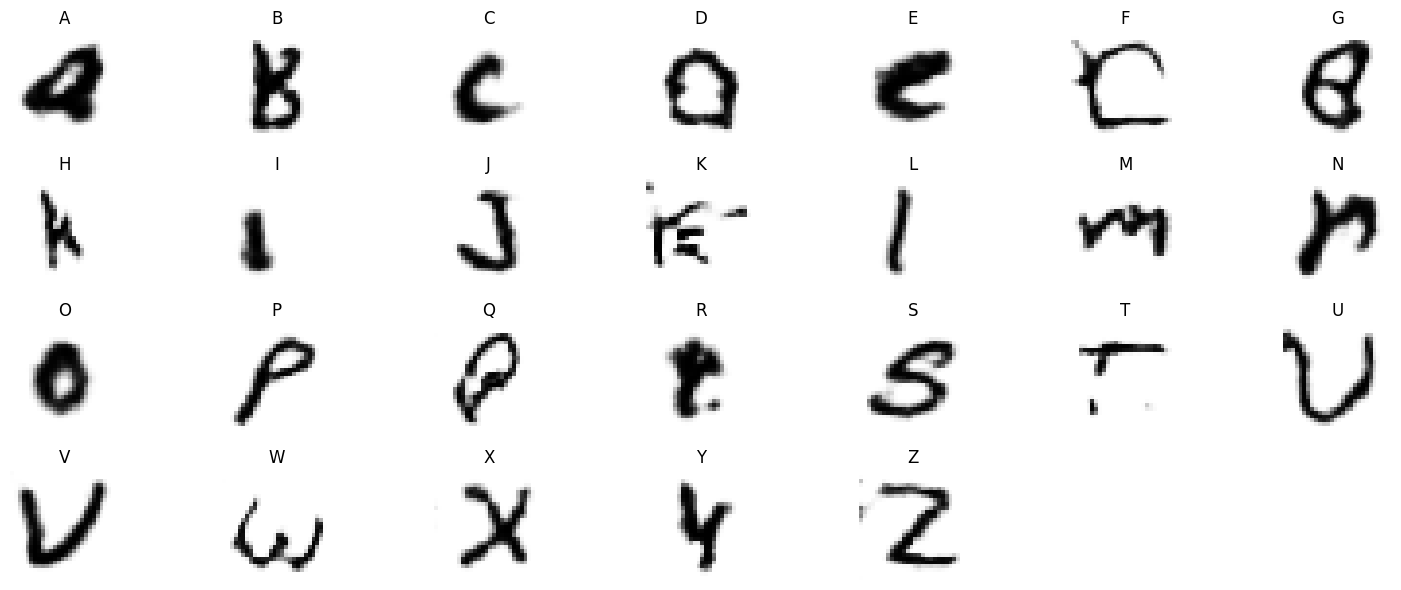

In [620]:
plt.figure(figsize=(15, 6))
for i in range(26):
    img = generate_letter(i)
    plt.subplot(4, 7, i+1)
    plt.imshow(img, cmap='gray')
    plt.title(chr(65+i))
    plt.axis('off')
plt.tight_layout()
plt.show()


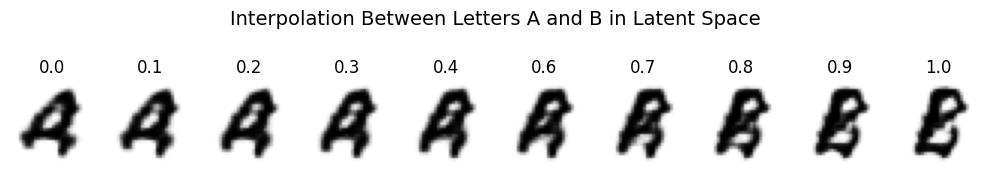

In [ ]:
def interpolate_letters(letter_id_start, letter_id_end, steps=10):
    noise = keras.random.normal(shape=(1, latent_dim))

    start_label = keras.utils.to_categorical([letter_id_start], num_classes)
    end_label   = keras.utils.to_categorical([letter_id_end], num_classes)

    plt.figure(figsize=(steps, 2))

    for i, alpha in enumerate(np.linspace(0, 1, steps)):
        interp_label = (1 - alpha) * start_label + alpha * end_label
        label = ops.cast(interp_label, "float32")

        img = trained_gen.predict(ops.concatenate([noise, label], axis=1), verbose=0)
        img = (img[0][:, :, 0] * 255).astype(np.uint8)
        img = 255 - img

        plt.subplot(1, steps, i+1)
        plt.imshow(img, cmap='gray')
        plt.axis('off')
        plt.title(f"{alpha:.1f}")

    plt.suptitle("Interpolation Between Letters A and B in Latent Space", fontsize=14)
    plt.tight_layout()
    plt.show()

interpolate_letters(letter_to_id['A'], letter_to_id['B'], steps=10)
